In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

sns.set_style("whitegrid")


In [ ]:
# Abrir y mostrar el archivo de resultados
df = pd.read_csv("./runs/train/final_results.csv")
df.head()

,Dataset,epoch,train/box_loss,train/obj_loss,train/cls_loss,metrics/precision,metrics/recall,metrics/mAP_0.5,metrics/mAP_0.5:0.95,val/box_loss,val/obj_loss,val/cls_loss,x/lr0,x/lr1,x/lr2
0,BDD100K,0,0.120700,0.069847,0.085012,0.000230,0.007063,0.000118,0.000028,0.124780,0.068484,0.090274,0.070068,0.003326,0.003326
1,BDD100K,1,0.112990,0.079676,0.078225,0.000377,0.010275,0.000223,0.000064,0.106070,0.086314,0.069838,0.040003,0.006593,0.006593
2,BDD100K,2,0.100980,0.074017,0.053689,0.926570,0.024302,0.016702,0.004857,0.087007,0.072778,0.048598,0.009871,0.009794,0.009794
3,BDD100K,3,0.085622,0.068209,0.049388,0.950910,0.032619,0.036659,0.014661,0.075521,0.066582,0.047377,0.009703,0.009703,0.009703
4,BDD100K,4,0.077912,0.065374,0.048057,0.958180,0.037045,0.047750,0.020672,0.070373,0.063162,0.046653,0.009703,0.009703,0.009703


In [ ]:
# Eliminar espacios vacíos en el nombre
for n in df.columns:
    nn = n.replace(" ","")
    df.rename(columns={n:nn}, inplace=True)
df.columns

Index(['Dataset', 'epoch', 'train/box_loss', 'train/obj_loss',
       'train/cls_loss', 'metrics/precision', 'metrics/recall',
       'metrics/mAP_0.5', 'metrics/mAP_0.5:0.95', 'val/box_loss',
       'val/obj_loss', 'val/cls_loss', 'x/lr0', 'x/lr1', 'x/lr2'],
      dtype='object')

In [ ]:
# Filtrar resultados de PacalVOC (200 --> 100 épocas)
df_filtered = df[
    (df["Dataset"] != "PascalVOC") | (df["epoch"] <= 100)
].copy()
df_filtered.tail(10)

,Dataset,epoch,train/box_loss,train/obj_loss,train/cls_loss,metrics/precision,metrics/recall,metrics/mAP_0.5,metrics/mAP_0.5:0.95,val/box_loss,val/obj_loss,val/cls_loss,x/lr0,x/lr1,x/lr2
291,PascalVOC,91,0.032900,0.029719,0.082398,0.75972,0.71036,0.76093,0.53012,0.031439,0.017946,0.079210,0.005545,0.005545,0.005545
292,PascalVOC,92,0.032822,0.029649,0.082442,0.76015,0.71223,0.76189,0.53073,0.031420,0.017934,0.079200,0.005496,0.005496,0.005496
293,PascalVOC,93,0.032830,0.029499,0.082264,0.76105,0.71065,0.76236,0.53134,0.031405,0.017923,0.079191,0.005446,0.005446,0.005446
294,PascalVOC,94,0.032904,0.029460,0.082273,0.76415,0.70844,0.76284,0.53193,0.031388,0.017908,0.079180,0.005397,0.005397,0.005397
295,PascalVOC,95,0.032568,0.029551,0.082091,0.76437,0.70988,0.76361,0.53238,0.031373,0.017895,0.079173,0.005347,0.005347,0.005347
296,PascalVOC,96,0.032529,0.029493,0.082396,0.76342,0.71410,0.76387,0.53310,0.031359,0.017883,0.079165,0.005298,0.005298,0.005298
297,PascalVOC,97,0.032531,0.029428,0.082010,0.76291,0.71540,0.76439,0.53374,0.031347,0.017870,0.079157,0.005248,0.005248,0.005248
298,PascalVOC,98,0.032508,0.029555,0.081872,0.76175,0.71583,0.76465,0.53410,0.031334,0.017858,0.079149,0.005198,0.005198,0.005198
299,PascalVOC,99,0.032397,0.029199,0.081964,0.77155,0.70903,0.76520,0.53471,0.031319,0.017844,0.079140,0.005149,0.005149,0.005149
300,PascalVOC,100,0.032355,0.029240,0.081835,0.77062,0.70913,0.76516,0.53475,0.031306,0.017833,0.079133,0.005099,0.005099,0.005099


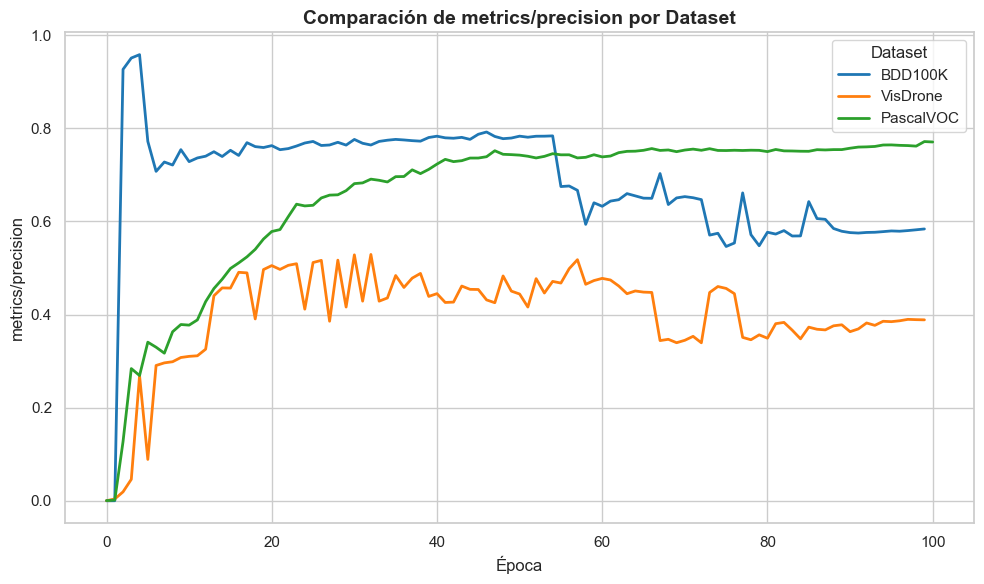

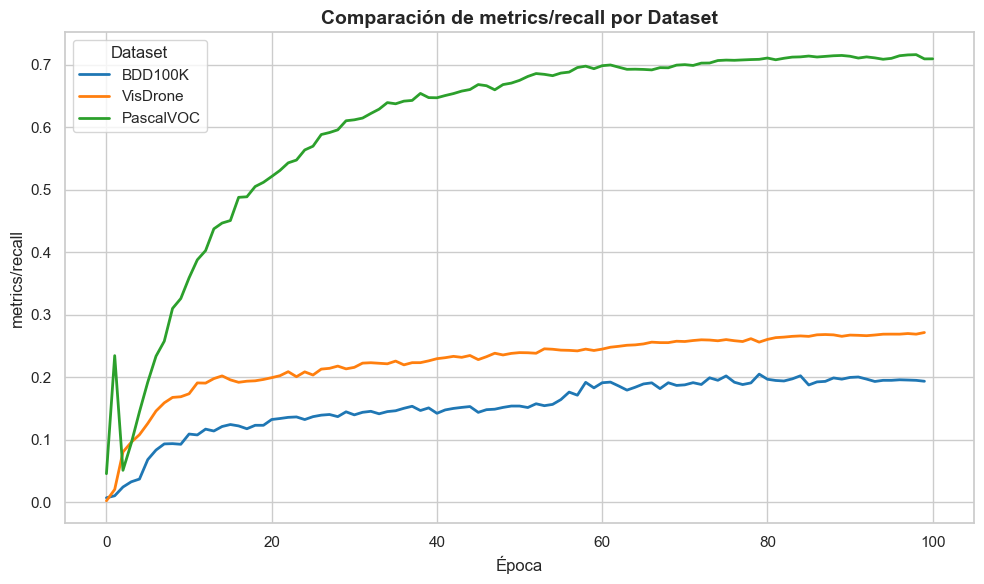

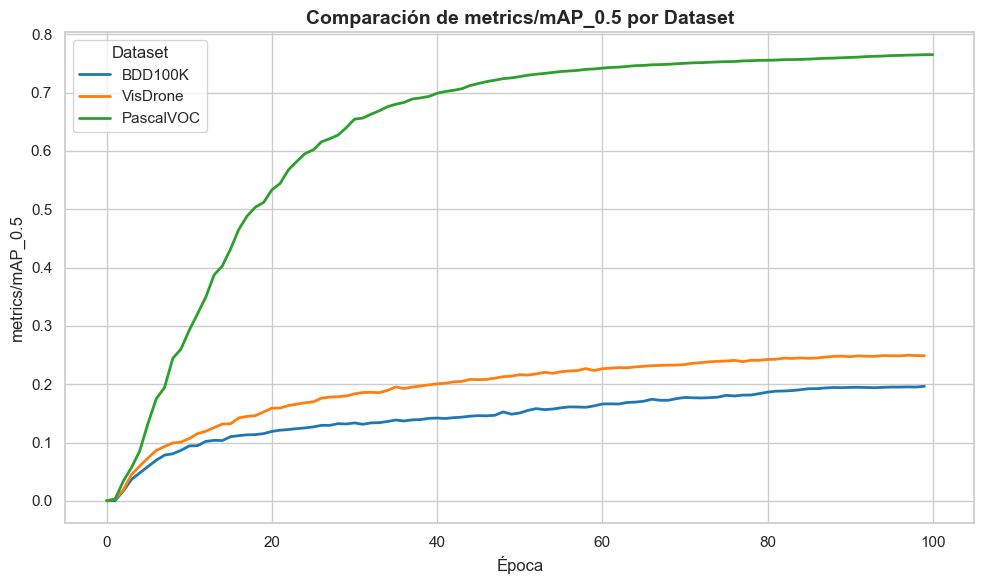

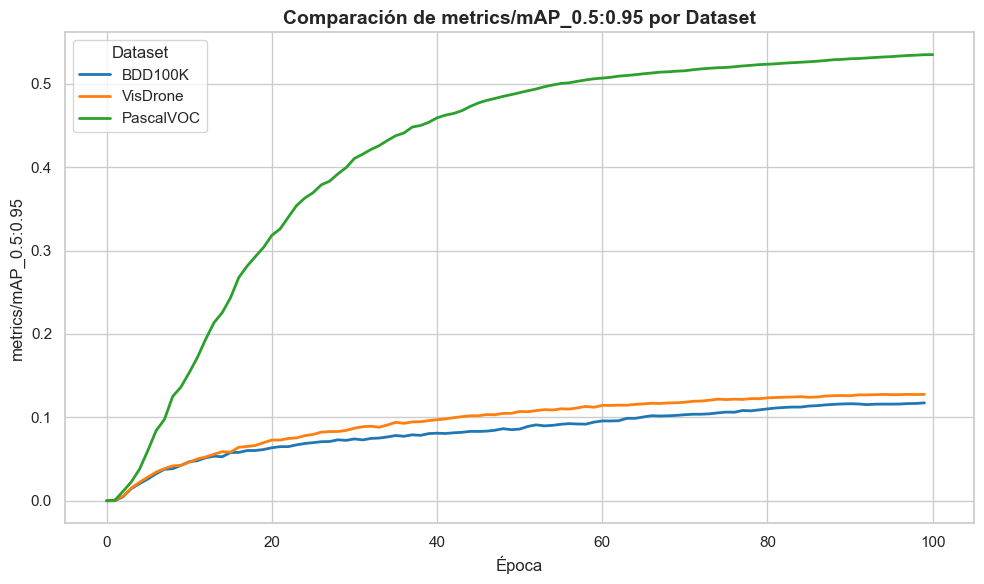

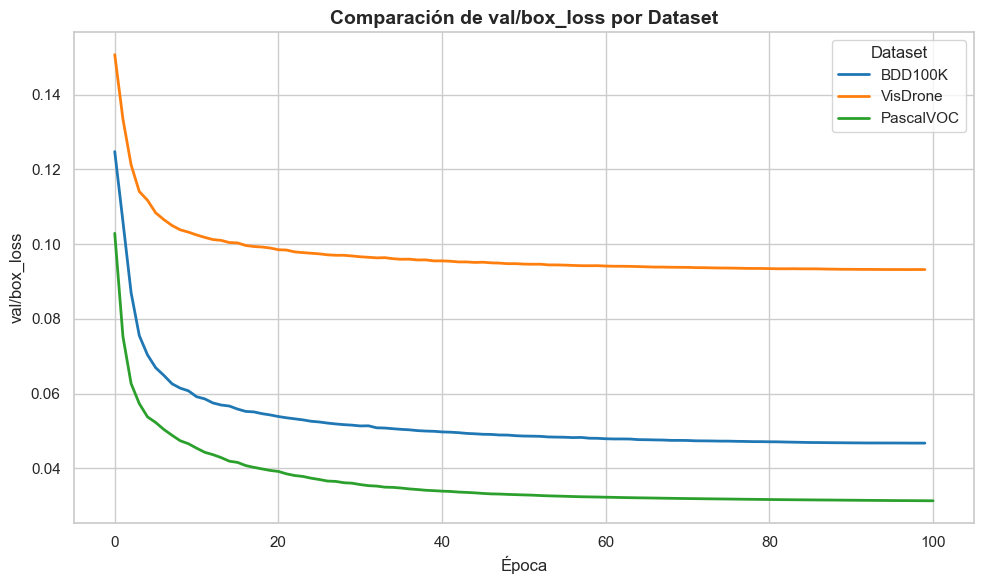

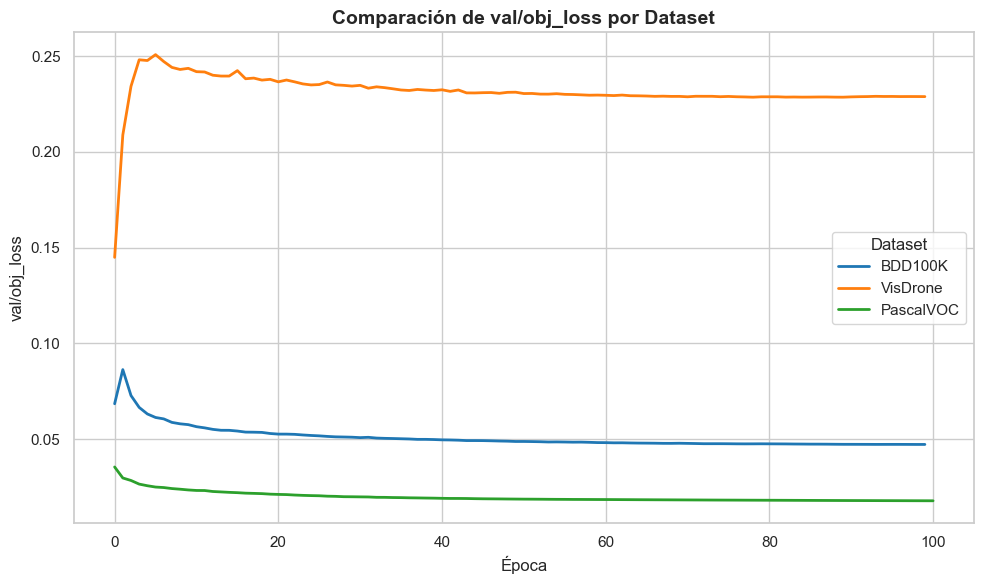

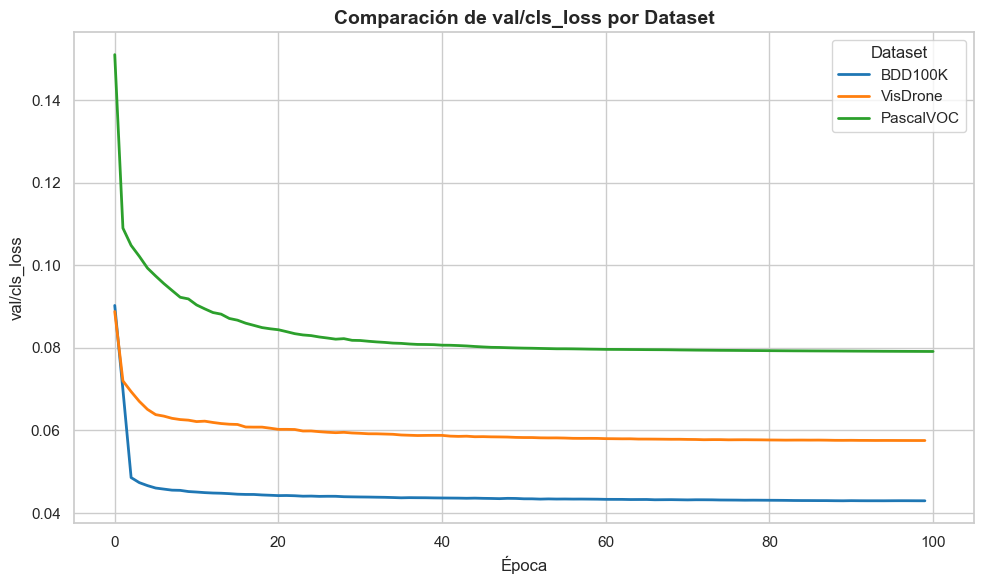

In [ ]:
# Métricas a visualizar
metrics = [
    "metrics/precision",
    "metrics/recall",
    "metrics/mAP_0.5",
    "metrics/mAP_0.5:0.95",
    "val/box_loss",
    "val/obj_loss",
    "val/cls_loss" 
]

# Generar gráfico por métricas
for metric in metrics:
    plt.figure(figsize=(10, 6))
    
    sns.lineplot(
        data=df_filtered,
        x="epoch",
        y=metric,
        hue="Dataset",
        linewidth=2
    )
    
    plt.title(f"Comparación de {metric} por Dataset", fontsize=14, weight='bold')
    plt.xlabel("Época")
    plt.ylabel(metric)
    plt.legend(title="Dataset")
    name = metric.replace("/","_")
    
    plt.tight_layout()

    # Guardar imágenes
    #plt.savefig(f"./runs/train/comparación_{name}.png")
    
    plt.show()


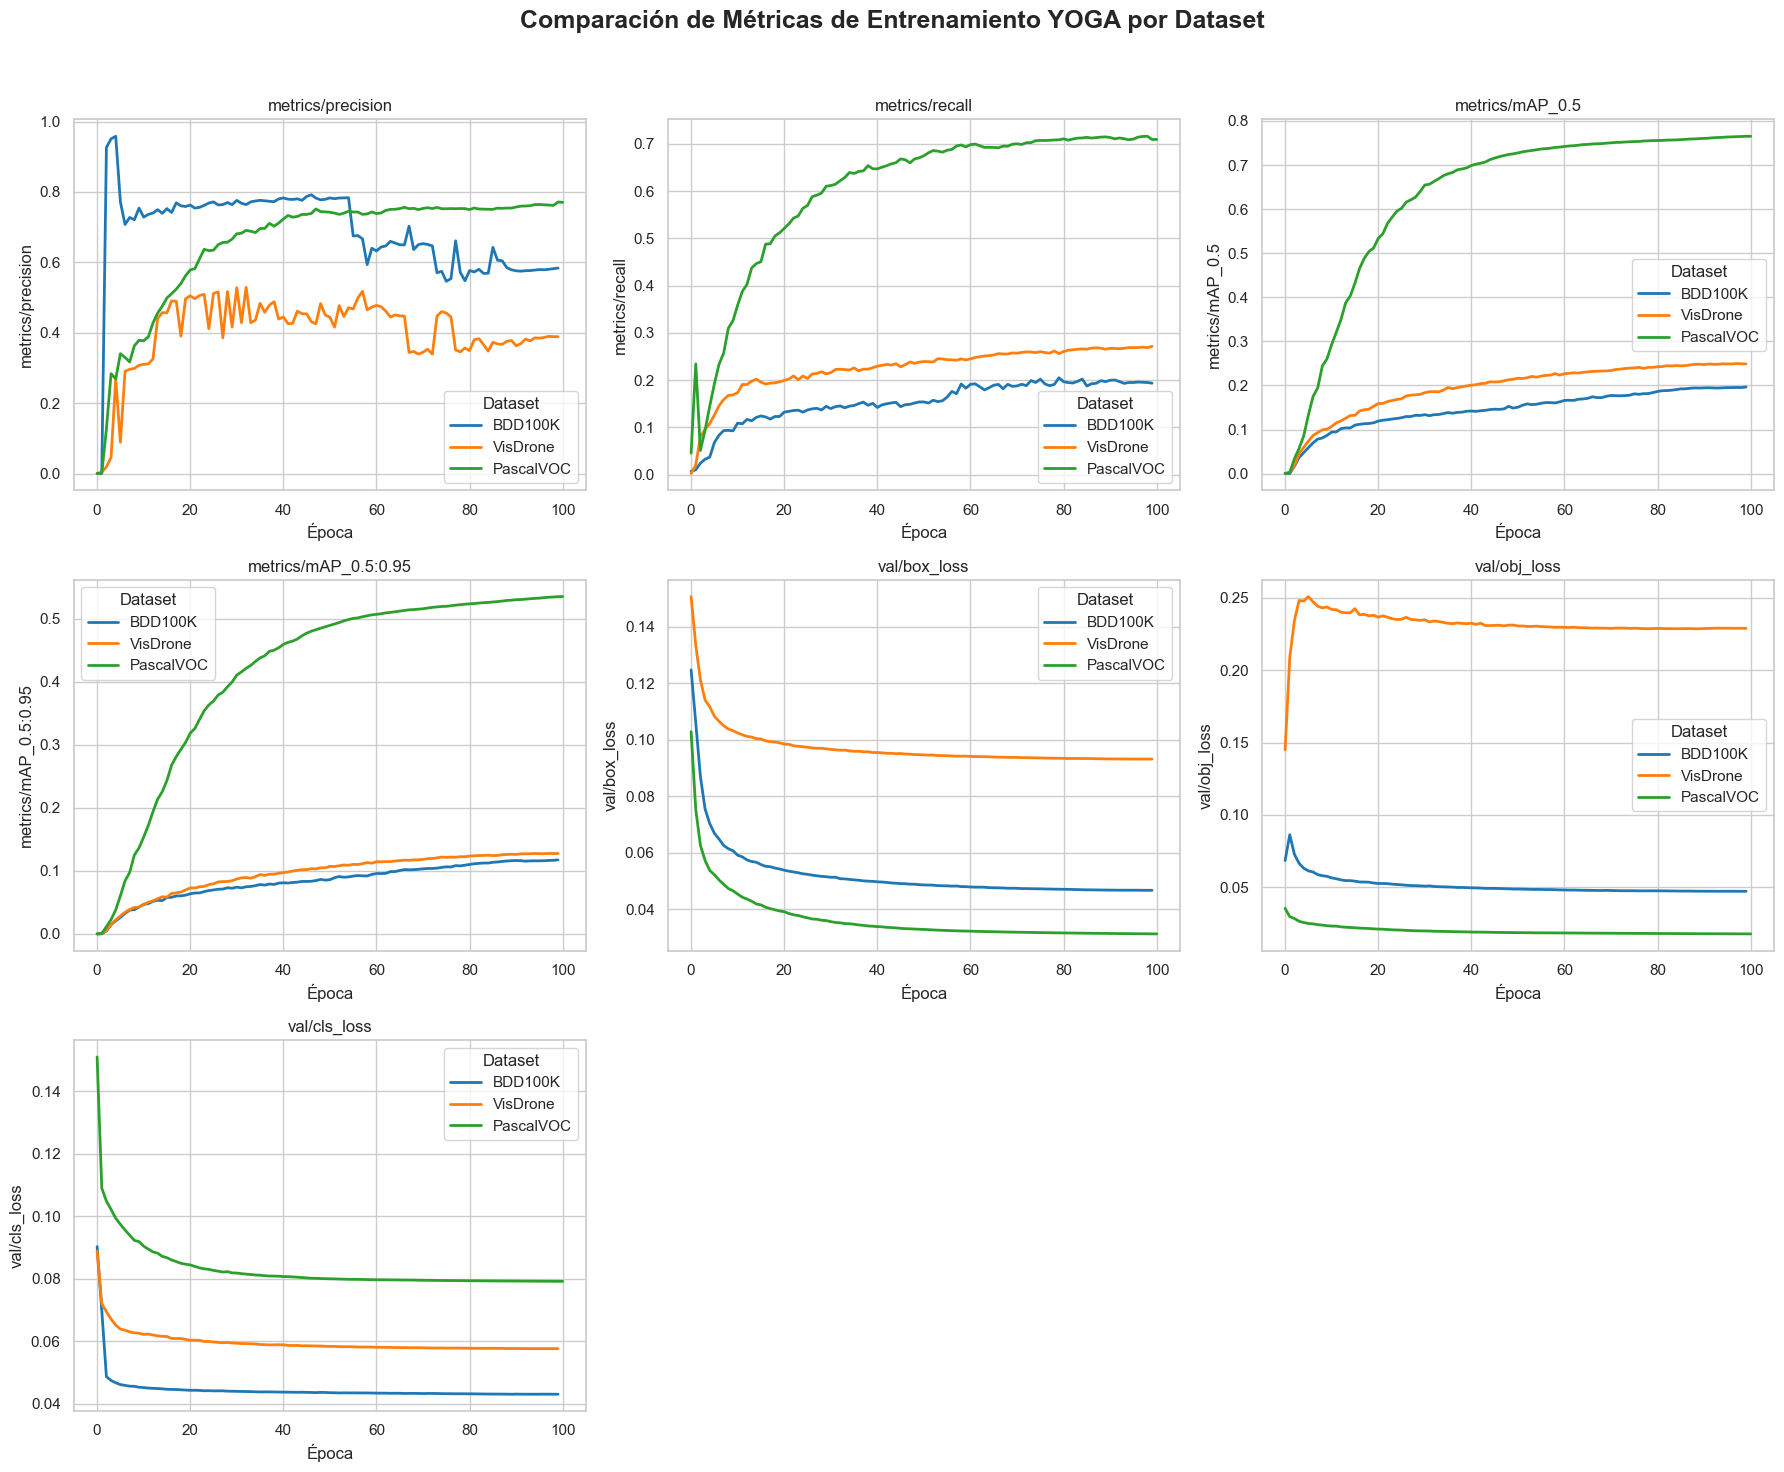

In [ ]:
# Preparación de resumen de resultados (3 columnas)
n_metrics = len(metrics)
cols = 3
rows = math.ceil(n_metrics / cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
axes = axes.flatten()

# Realizar gráfico
for i, metric in enumerate(metrics):
    sns.lineplot(
        data=df_filtered,
        x="epoch",
        y=metric,
        hue="Dataset",
        ax=axes[i],
        linewidth=2
    )
    
    axes[i].set_title(metric)
    axes[i].set_xlabel("Época")
    axes[i].set_ylabel(metric)

# Eliminar ejes vacíos
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Título del gráfico
fig.suptitle(
    "Comparación de Métricas de Entrenamiento YOGA por Dataset",
    fontsize=18,
    weight='bold'
)

# Ajuste para que no se sobreponga el título
plt.tight_layout(rect=[0, 0, 1, 0.96])

# Guardar imagen
#plt.savefig("summary_subplot.png")

plt.show()